# imports

In [1]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# load data

In [2]:
# src : https://www.kaggle.com/datasets/jahaidulislam/car-specification-dataset-1945-2020?select=Car+Dataset+1945-2020.csv
df = pd.read_csv("res/car-dataset-1945-2020.csv")
df['city_fuel_per_100km_l'].isnull().sum()

#Car with the highest hp
df['engine_hp'].idxmax()
df.loc[df['engine_hp'].idxmax()]



C:\Users\gaeta\AppData\Local\Temp\ipykernel_33836\1140561735.py:2: DtypeWarning: Columns (9,11,12,13,14,15,16,17,19,20,24,27,29,33,43,44,47,49,51,69,75,77) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("res/car-dataset-1945-2020.csv")


id_trim                             53323
Make                                Rimac
Modle                               C Two
Generation                   1 generation
Year_from                          2018.0
                                 ...     
safety_assessment                     NaN
rating_name                           NaN
battery_capacity_KW_per_h             NaN
electric_range_km                     NaN
charging_time_h                       NaN
Name: 53199, Length: 78, dtype: object

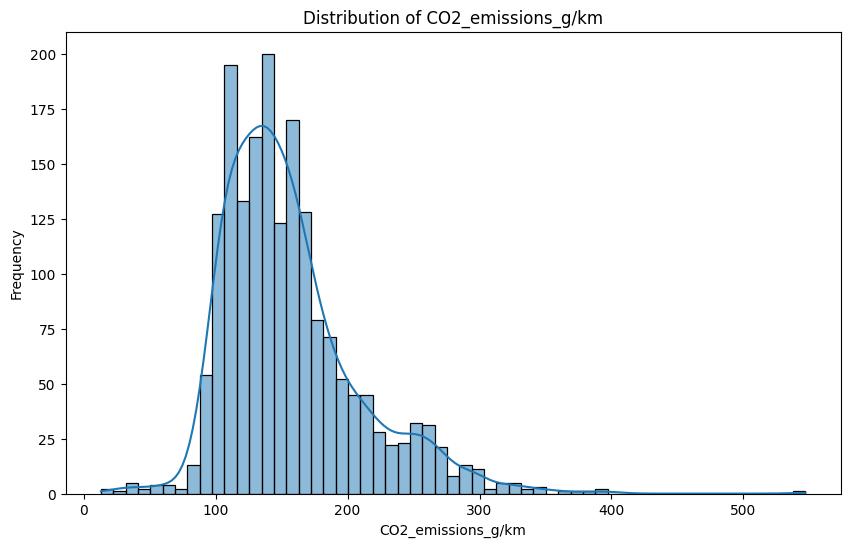

In [3]:
column = 'CO2_emissions_g/km'

plt.figure(figsize=(10, 6))
sns.histplot(df[column].dropna(), kde=True)
plt.title(f'Distribution of {column}')
plt.xlabel(column)
plt.ylabel('Frequency')
plt.show()

#type(df['number_of_seats'].head(1)[0])
#df[column].between(0, 500).sum()


# preprocessing

In [ ]:
# Remove unnecessary columns and rename selected columns

columns_to_keep = [
    # Main
    "Make",
    "Modle",
    "Year_from",
    "Year_to",
    "Body_type",
    "car_class",
    "number_of_seats",

    # Engine
    "engine_type",
    "capacity_cm3",
    "engine_hp",
    "maximum_torque_n_m",
    "number_of_cylinders",
    "cylinder_layout",

    # Weight
    "curb_weight_kg",

    # Consumption
    "mixed_fuel_consumption_per_100_km_l",
    "city_fuel_per_100km_l",
    "highway_fuel_per_100km_l",
    "CO2_emissions_g/km",
    "emission_standards",
    "range_km",
    "fuel_grade",

    # Performance
    "acceleration_0_100_km/h_s",
    "max_speed_km_per_h",
]

df = df.loc[:, columns_to_keep].rename(
    columns={
        "Make": "manufacturer",
        "Modle": "model",
        "Year_from": "year_from",
        "Year_to": "year_to",
        "Body_type": "body_type",
        "car_class": "car_class",
        "CO2_emissions_g/km": "co2_emissions_g_per_km",
        "acceleration_0_100_km/h_s": "acceleration_0_100_km_h_s",
    }
)

df[['torque_nm', 'torque_rpm']] = df['maximum_torque_n_m'].astype(str).str.split('/', expand=True)
df['torque_nm'] = pd.to_numeric(df['torque_nm'], errors='coerce')
df['torque_rpm'] = pd.to_numeric(df['torque_rpm'], errors='coerce')



df[['range_city_km', 'range_highway_km']] = df['range_km'].astype(str).str.split('|', expand=True)
df['range_city_km'] = pd.to_numeric(df['range_city_km'], errors='coerce')
df['range_highway_km'] = pd.to_numeric(df['range_highway_km'], errors='coerce')
    
df

,manufacturer,model,year_from,year_to,body_type,car_class,number_of_seats,engine_type,capacity_cm3,engine_hp,...,co2_emissions_g_per_km,emission_standards,range_km,fuel_grade,acceleration_0_100_km_h_s,max_speed_km_per_h,torque_nm,torque_rpm,range_city_km,range_highway_km
0,AC,ACE,1993.0,2000.0,Cabriolet,NaN,2,Gasoline,3505.0,354.0,...,NaN,NaN,"450|1,000",95,5.0,250,407.0,NaN,450.0,NaN
1,AC,ACE,1993.0,2000.0,Cabriolet,NaN,2,Gasoline,4601.0,326.0,...,NaN,NaN,600|900,98,5.0,250,427.0,NaN,600.0,900.0
2,AC,ACE,1993.0,2000.0,Cabriolet,NaN,2,Gasoline,4942.0,260.0,...,NaN,NaN,NaN,95,NaN,225,434.0,NaN,NaN,NaN
3,AC,ACE,1993.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AC,ACE,1993.0,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70818,ZX,Landmark,2007.0,2009.0,NaN,J,5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70819,ZX,Landmark,2007.0,2009.0,NaN,J,5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70820,ZX,Landmark,2007.0,2009.0,NaN,J,5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70821,ZX,Landmark,2007.0,2009.0,NaN,J,5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


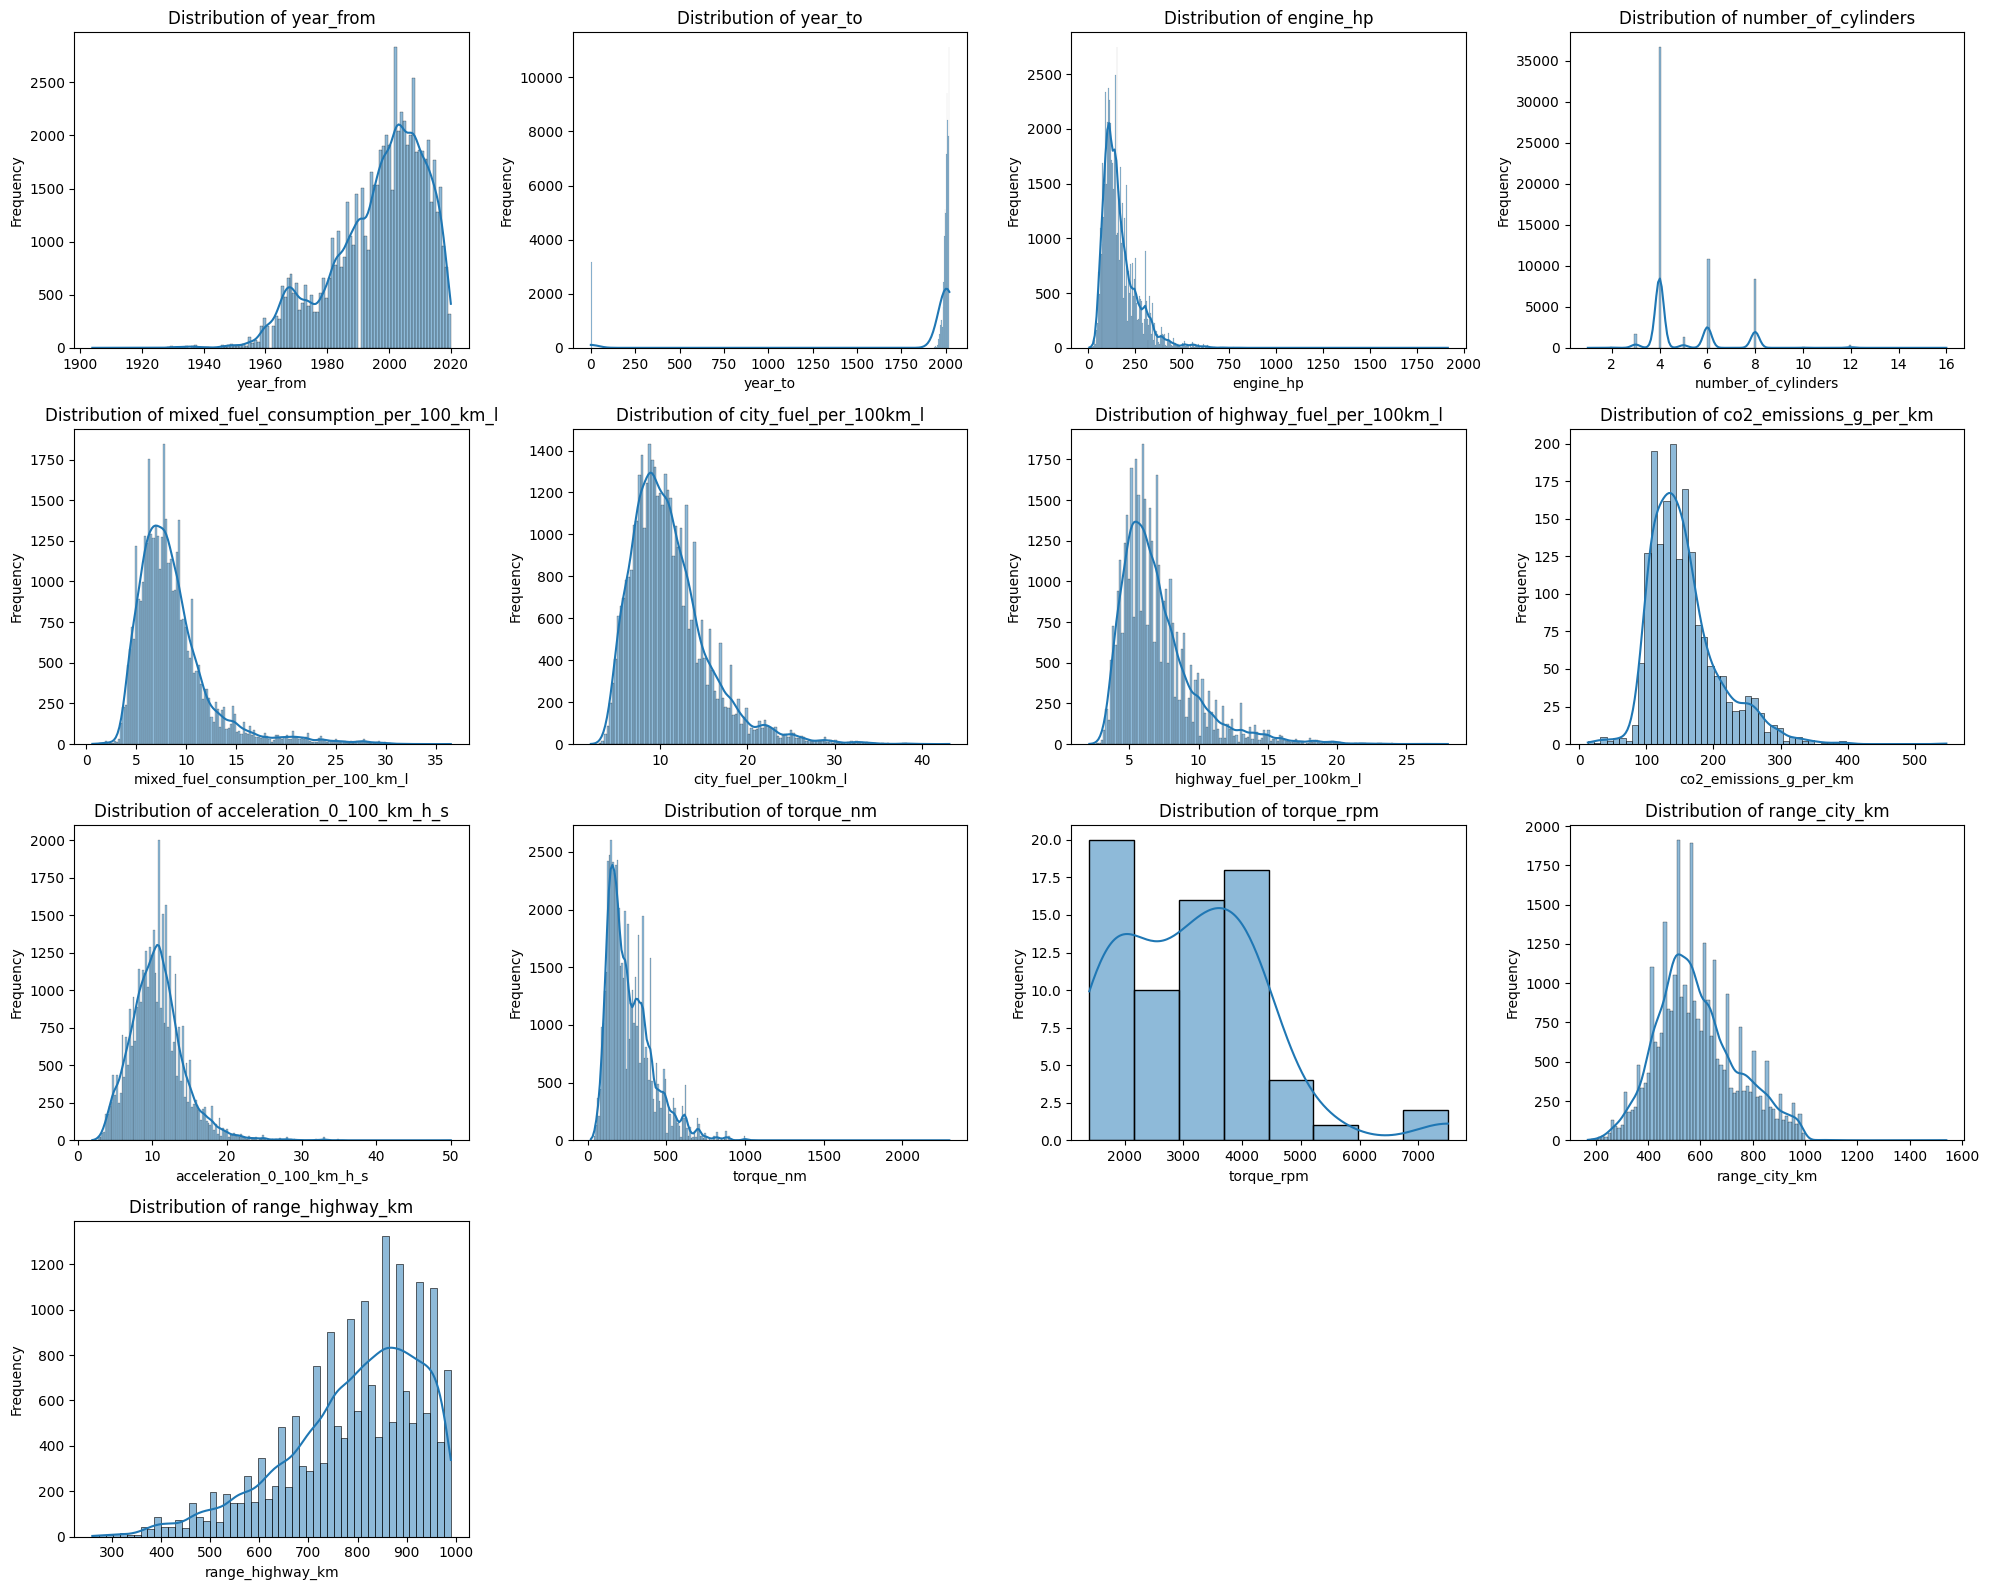

In [5]:
# Plotting every column in subplots
import math
n_cols = 4
numeric_cols = df.select_dtypes(include='number').columns.tolist()
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, column in enumerate(numeric_cols):
    try:
        sns.histplot(df[column].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {column}')
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Frequency')
    except Exception as e:
        print(f"Could not plot {column}: {e}")

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [6]:
#Replace , with . in the columns, 
columns_to_replace = [
    "capacity_cm3",
    "engine_hp",
    "curb_weight_kg",
    "mixed_fuel_consumption_per_100_km_l",
    "city_fuel_per_100km_l",
    "highway_fuel_per_100km_l",
    "co2_emissions_g_per_km",
    "acceleration_0_100_km_h_s",
    "max_speed_km_per_h"
]

#and remove km/h in the max_speed_km_per_h column

for column in columns_to_replace:
    try:
        if column == "max_speed_km_per_h":
            df[column] = (df[column].astype(str)
                          .str.replace('km/h', '', regex=False)
                          .str.replace(',', '.', regex=False)
                          .str.strip()
                          .replace('', float('nan'))  
                          .replace('nan', float('nan')) 
                          .pipe(pd.to_numeric, errors='coerce'))
        else:
            df[column] = df[column].astype(str).str.replace(',', '.').astype(float)
    except Exception as e:
        print(f"Could not convert {column}: {e}")

